# Unemployment Analysis with Python
**OIBSIP Data Analytics Internship — Task 2**

**Author:** Letsoenyo Clen Bongane
**Objective:** Perform exploratory data analysis on unemployment data to
uncover regional and temporal trends, with a focus on the impact of the
COVID-19 pandemic on unemployment rates in India.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 1. Load the Dataset
Downloaded from Kaggle: "Unemployment in India" dataset.
Place the CSV in a `data/` folder next to this script before running.

In [2]:
df = pd.read_csv("data/Unemployment in India.csv")

# This dataset is notorious for leading/trailing whitespace in column names
# and string values — clean that up immediately so nothing downstream breaks.
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


## 2. Data Loading, Shape, and Type Inspection

In [3]:
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nData types:\n", df.dtypes)
print("\nNull values per column:\n", df.isnull().sum())

Shape: (768, 7)

Columns: ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']

Data types:
 Region                                      object
Date                                        object
Frequency                                   object
Estimated Unemployment Rate (%)            float64
Estimated Employed                         float64
Estimated Labour Participation Rate (%)    float64
Area                                        object
dtype: object

Null values per column:
 Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64


In [4]:
# Drop fully-empty rows if any exist (this dataset sometimes has trailing blanks)
df = df.dropna(how="all")

# Convert Date to a real datetime column
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")

# Rename the long columns to something easier to work with
df = df.rename(columns={
    "Estimated Unemployment Rate (%)": "Unemployment_Rate",
    "Estimated Employed": "Employed",
    "Estimated Labour Participation Rate (%)": "Labour_Participation_Rate",
})

df = df.dropna(subset=["Date", "Unemployment_Rate"])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Region                     740 non-null    object        
 1   Date                       740 non-null    datetime64[ns]
 2   Frequency                  740 non-null    object        
 3   Unemployment_Rate          740 non-null    float64       
 4   Employed                   740 non-null    float64       
 5   Labour_Participation_Rate  740 non-null    float64       
 6   Area                       740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 46.2+ KB


## 3. Exploratory Data Analysis

In [5]:
# Region-wise average unemployment rate
region_avg = (
    df.groupby("Region")["Unemployment_Rate"]
    .mean()
    .sort_values(ascending=False)
)
region_avg.head(10)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Unemployment_Rate, dtype: float64

In [6]:
# Month-wise national trend
df["Month"] = df["Date"].dt.to_period("M").dt.to_timestamp()
monthly_trend = df.groupby("Month")["Unemployment_Rate"].mean()
monthly_trend

Month
2019-05-01     8.874259
2019-06-01     9.303333
2019-07-01     9.033889
2019-08-01     9.637925
2019-09-01     9.051731
2019-10-01     9.900909
2019-11-01     9.868364
2019-12-01     9.497358
2020-01-01     9.950755
2020-02-01     9.964717
2020-03-01    10.700577
2020-04-01    23.641569
2020-05-01    24.875294
2020-06-01    11.903600
Name: Unemployment_Rate, dtype: float64

## 4. Time-Series Trend: Unemployment Rate Over Time
Showing the 3 states with the highest average unemployment rate over the
full time period, to see how their trends compare.

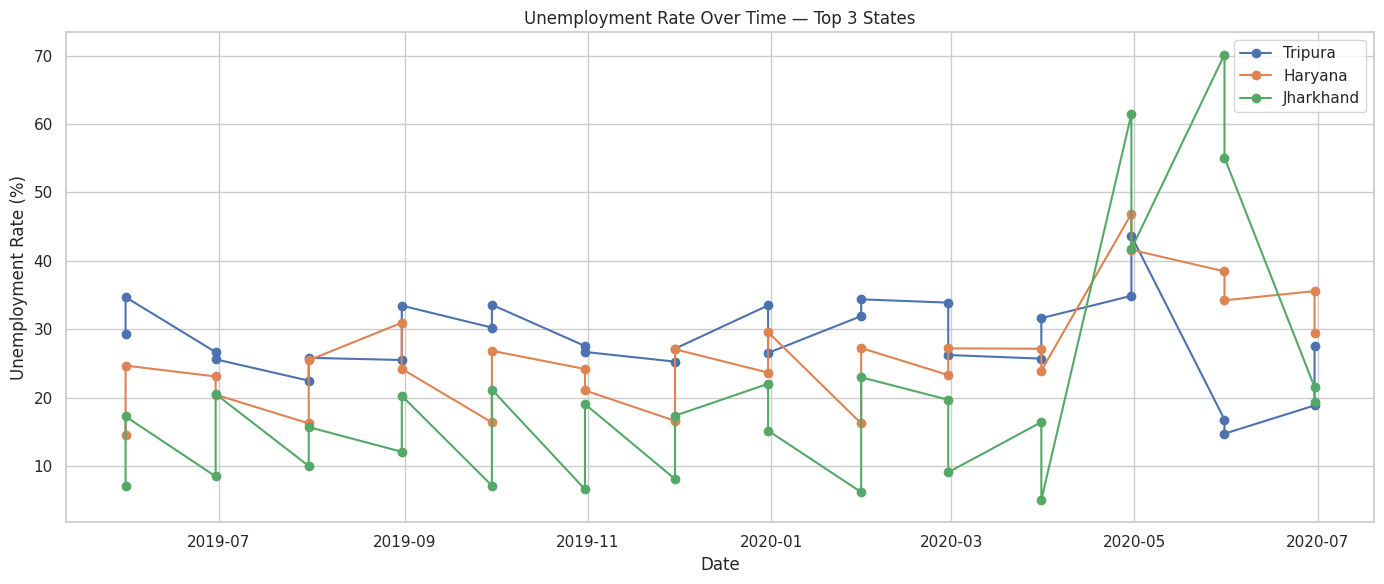

In [7]:
top3_states = region_avg.head(3).index.tolist()

fig, ax = plt.subplots(figsize=(14, 6))
for state in top3_states:
    state_data = df[df["Region"] == state].sort_values("Date")
    ax.plot(state_data["Date"], state_data["Unemployment_Rate"], marker="o", label=state)

ax.set_title("Unemployment Rate Over Time — Top 3 States")
ax.set_xlabel("Date")
ax.set_ylabel("Unemployment Rate (%)")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Top 10 States by Average Unemployment Rate

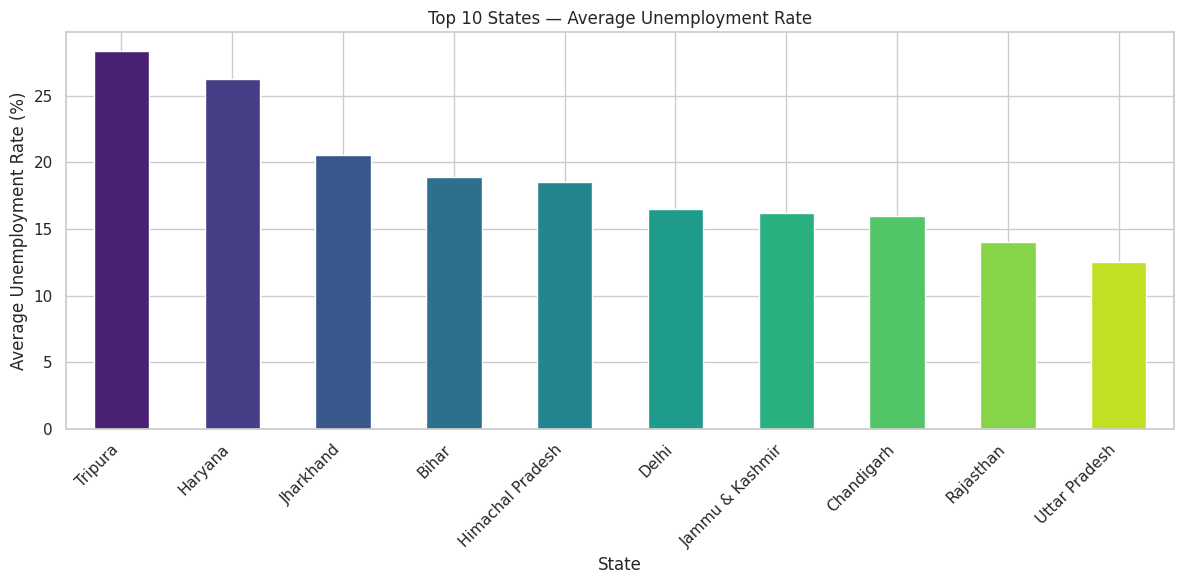

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))
region_avg.head(10).plot(kind="bar", ax=ax, color=sns.color_palette("viridis", 10))
ax.set_title("Top 10 States — Average Unemployment Rate")
ax.set_xlabel("State")
ax.set_ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6. Correlation Heatmap
Correlation between unemployment rate, employment count, and labour
participation rate.

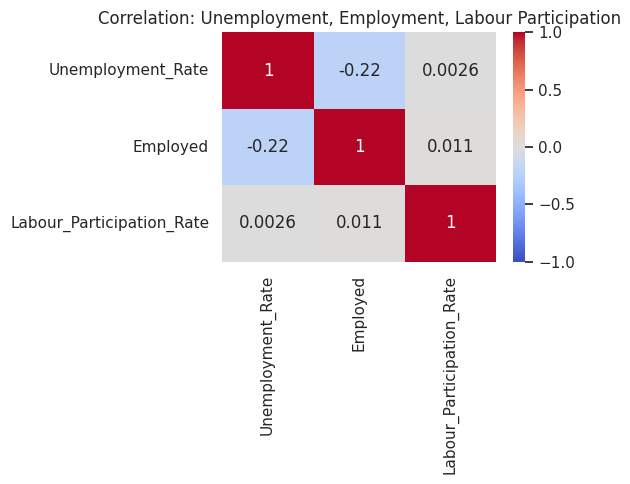

In [9]:
corr_cols = ["Unemployment_Rate", "Employed", "Labour_Participation_Rate"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation: Unemployment, Employment, Labour Participation")
plt.tight_layout()
plt.show()

## 7. Pre-COVID vs. Post-COVID Comparison
Splitting the data at March 2020 — widely marked as when India's COVID-19
lockdowns began impacting the labour market.

In [10]:
cutoff = pd.Timestamp("2020-03-01")
pre_covid = df[df["Date"] < cutoff]
post_covid = df[df["Date"] >= cutoff]

comparison = pd.DataFrame({
    "Pre-COVID Mean": [
        pre_covid["Unemployment_Rate"].mean(),
        pre_covid["Employed"].mean(),
        pre_covid["Labour_Participation_Rate"].mean(),
    ],
    "Post-COVID Mean": [
        post_covid["Unemployment_Rate"].mean(),
        post_covid["Employed"].mean(),
        post_covid["Labour_Participation_Rate"].mean(),
    ],
}, index=["Unemployment Rate (%)", "Employed", "Labour Participation Rate (%)"])

comparison["% Change"] = (
    (comparison["Post-COVID Mean"] - comparison["Pre-COVID Mean"])
    / comparison["Pre-COVID Mean"] * 100
)
comparison

,Pre-COVID Mean,Post-COVID Mean,% Change
Unemployment Rate (%),9.509534e+00,1.777436e+01,86.910984
Employed,7.466028e+06,6.517203e+06,-12.708559
Labour Participation Rate (%),4.388612e+01,3.933005e+01,-10.381575



**Observations:**
**The pre/post-COVID jump is stark**: national average unemployment rose from 9.51% pre-COVID to 17.77% post-COVID — an **86.9% increase**. This lines up exactly with India's late-March 2020 lockdown; the monthly trend shows the rate climbing from 9.95% in January 2020 to 23.64% in April 2020 alone, before partially recovering by June.
**Employment and labour participation moved in the same direction**, not opposite ones: Employed count fell 12.7% and Labour Participation Rate fell 10.4% post-COVID. This is an important distinction — the unemployment spike wasn't just people losing jobs while still job-hunting; a meaningful share of the workforce also **left the labour force entirely** (stopped seeking work), which is consistent with lockdown restrictions making job search itself impossible for a period.
**Jharkhand, Tripura, and Haryana** (the 3 highest-average states) all show a dramatic spike in the April 2020 window, with Jharkhand peaking above 60–70% — likely reflecting a heavy reliance on informal or migrant labour, sectors hit hardest by sudden lockdown restrictions.
**The correlation heatmap is a useful sanity check but not a strong signal on its own**: Unemployment Rate vs. Employed shows only a weak negative correlation (-0.22), and vs. Labour Participation Rate is essentially zero (0.003). This makes sense — these are state-and-month-level snapshots, not a single continuous trend, so a national shock like COVID shows up more clearly in the time-series view than in a flat correlation across all rows.

# 8. Conclusion

This analysis confirms COVID-19's severe, measurable impact on India's labour market: national unemployment nearly doubled (9.5% → 17.8%) in the immediate 
lockdown period, with the worst-hit states — Jharkhand, Tripura, and Haryana — seeing unemployment spike above 60% for a single month before partially 
recovering. Critically, the data shows this wasn't only a story of layoffs: both employment count and labour force participation dropped simultaneously, 
indicating many people were pushed out of the labour market entirely rather than just left unemployed within it. For a policymaker, this suggests recovery
support needs to address not just job creation, but also re-engagement of workers who exited the labour force — reskilling and outreach programs, 
not just vacancy postings, since a lower participation rate means fewer people were even actively looking.